In [4]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_excel("D:3\megapik_raw_movie_data.xlsx")
df.head()

,Movie Name,Release Date,Opening Night Revenue ($M),Opening Weekend Revenue ($M),Budget ($M),Marketing Costs ($M),Ratings,Genre
0,Legacy of Kingdom 1,2010-01-04,12.42,41.50,73.30,36.50,PG-13,Animation
1,Quest for Thunder 2,2010-01-06,2.13,7.17,9.99,4.71,PG-13,Drama
2,Tales of Echoes 3,2010-01-10,9.35,30.34,60.04,29.37,R,Action
3,Quest for Night 4,2010-02-24,12.21,35.85,39.08,17.29,PG-13,Adventure
4,Legacy of Frontier 5,2010-02-25,3.19,9.34,30.03,12.67,PG,Sci-Fi


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Movie Name                    500 non-null    object 
 1   Release Date                  500 non-null    object 
 2   Opening Night Revenue ($M)    500 non-null    float64
 3   Opening Weekend Revenue ($M)  500 non-null    float64
 4   Budget ($M)                   500 non-null    float64
 5   Marketing Costs ($M)          500 non-null    float64
 6   Ratings                       500 non-null    object 
 7   Genre                         500 non-null    object 
dtypes: float64(4), object(4)
memory usage: 31.4+ KB


In [7]:
df['Release Date']=pd.to_datetime(df['Release Date'])

In [11]:
#MAKING NEW COLUMS FOR RELEASE YEAR AND MONTH AND QUARTER
df['Release Year']=df['Release Date'].dt.strftime("%Y")
df['Release Month']=df['Release Date'].dt.strftime("%b-%Y")
df['Release Quarter']=df['Release Date'].dt.to_period('Q').dt.strftime("Q-%q")

In [35]:
#TOTAL INVESTMENT
df['Total Cost']=df['Budget ($M)']+df['Marketing Costs ($M)']

In [36]:
#OPEINING WEEKEND VELOCITY
df['Opening Night Share']=df['Opening Night Revenue ($M)']/df['Opening Weekend Revenue ($M)'].div(100)
#OPEING ROI MARGIN
df['Opening ROI']=(df['Opening Weekend Revenue ($M)'] - df['Total Cost'])/df['Total Cost']

In [32]:
df.head()

,Movie Name,Release Date,Opening Night Revenue ($M),Opening Weekend Revenue ($M),Budget ($M),Marketing Costs ($M),Ratings,Genre,Release Year,Release Month,Release Quarter,Total Investment,Opening Night Share,Opening ROI
0,Legacy of Kingdom 1,2010-01-04,12.42,41.50,73.30,36.50,PG-13,Animation,2010,Jan-2010,Q-1,109.80,29.927711,-0.622040
1,Quest for Thunder 2,2010-01-06,2.13,7.17,9.99,4.71,PG-13,Drama,2010,Jan-2010,Q-1,14.70,29.707113,-0.512245
2,Tales of Echoes 3,2010-01-10,9.35,30.34,60.04,29.37,R,Action,2010,Jan-2010,Q-1,89.41,30.817403,-0.660664
3,Quest for Night 4,2010-02-24,12.21,35.85,39.08,17.29,PG-13,Adventure,2010,Feb-2010,Q-1,56.37,34.058577,-0.364023
4,Legacy of Frontier 5,2010-02-25,3.19,9.34,30.03,12.67,PG,Sci-Fi,2010,Feb-2010,Q-1,42.70,34.154176,-0.781265


In [41]:

genre_summary = (
    df.groupby('Genre')
    .agg(
        Count=('Movie Name', 'count'),
        Avg_Budget=('Budget ($M)', 'mean'),
        Avg_Opening_Weekend=('Opening Weekend Revenue ($M)', 'mean'),
    )
    .sort_values(by='Avg_Opening_Weekend', ascending=False)
)

print(genre_summary)

           Count  Avg_Budget  Avg_Opening_Weekend
Genre                                            
Action       110   85.521000            71.656727
Sci-Fi        33   79.237879            62.230909
Adventure     79   76.379241            62.036962
Animation     58   68.128276            56.287586
Thriller      27   40.328519            33.552963
Comedy        75   38.203733            33.193867
Drama         72   24.976667            18.115556
Horror        46   14.653478            12.231087


C:\Users\DELL\AppData\Local\Temp\ipykernel_1492\949857378.py:140: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\DELL\AppData\Local\Temp\ipykernel_1492\949857378.py:168: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax4.set_xticklabels(genre_order, rotation=30, ha='right', fontweight='bold')


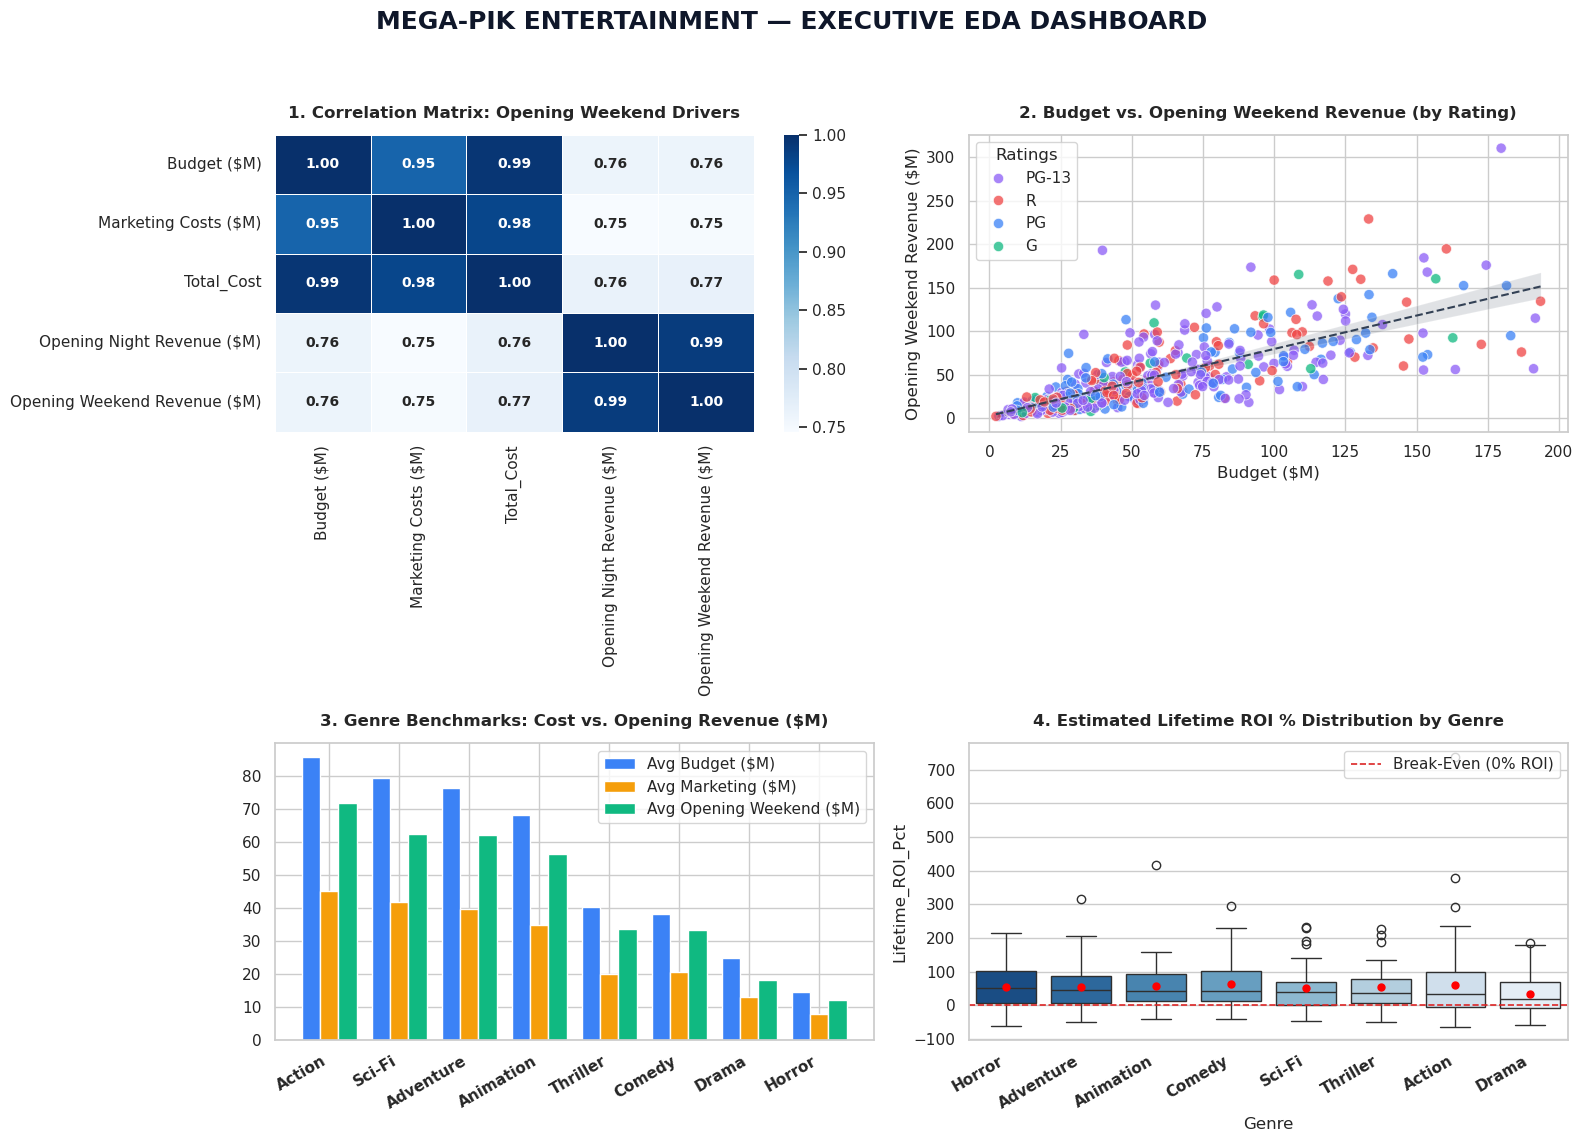

In [40]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Set style
sns.set_theme(style='whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

# Load data & calculate metrics
df['Total_Cost'] = df['Budget ($M)'] + df['Marketing Costs ($M)']
df['Est_Total_Revenue'] = df['Opening Weekend Revenue ($M)'] * 2.8
df['Lifetime_ROI_Pct'] = (
    (df['Est_Total_Revenue'] - df['Total_Cost']) / df['Total_Cost']
) * 100

# 2x2 Dashboard Figure
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(
    'MEGA-PIK ENTERTAINMENT — EXECUTIVE EDA DASHBOARD',
    fontsize=18,
    fontweight='bold',
    y=0.98,
    color='#0F172A',
)

# 1. Correlation Matrix
ax1 = axes[0, 0]
num_cols = [
    'Budget ($M)',
    'Marketing Costs ($M)',
    'Total_Cost',
    'Opening Night Revenue ($M)',
    'Opening Weekend Revenue ($M)',
]
sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap='Blues',
    fmt='.2f',
    cbar=True,
    ax=ax1,
    linewidths=0.5,
    annot_kws={'size': 10, 'weight': 'bold'},
)
ax1.set_title(
    '1. Correlation Matrix: Opening Weekend Drivers',
    fontsize=12,
    fontweight='bold',
    pad=12,
)

# 2. Budget vs Opening Weekend
ax2 = axes[0, 1]
palette_ratings = {
    'G': '#10B981',
    'PG': '#3B82F6',
    'PG-13': '#8B5CF6',
    'R': '#EF4444',
}
sns.scatterplot(
    data=df,
    x='Budget ($M)',
    y='Opening Weekend Revenue ($M)',
    hue='Ratings',
    palette=palette_ratings,
    alpha=0.75,
    s=55,
    ax=ax2,
)
sns.regplot(
    data=df,
    x='Budget ($M)',
    y='Opening Weekend Revenue ($M)',
    scatter=False,
    ax=ax2,
    color='#334155',
    line_kws={'linestyle': '--', 'linewidth': 1.5},
)
ax2.set_title(
    '2. Budget vs. Opening Weekend Revenue (by Rating)',
    fontsize=12,
    fontweight='bold',
    pad=12,
)

# 3. Genre Benchmarks
ax3 = axes[1, 0]
genre_perf = (
    df.groupby('Genre')
    .agg(
        Avg_Budget=('Budget ($M)', 'mean'),
        Avg_Marketing=('Marketing Costs ($M)', 'mean'),
        Avg_Opening=('Opening Weekend Revenue ($M)', 'mean'),
    )
    .sort_values(by='Avg_Opening', ascending=False)
)

x = np.arange(len(genre_perf))
width = 0.26
ax3.bar(
    x - width,
    genre_perf['Avg_Budget'],
    width,
    label='Avg Budget ($M)',
    color='#3B82F6',
)
ax3.bar(
    x,
    genre_perf['Avg_Marketing'],
    width,
    label='Avg Marketing ($M)',
    color='#F59E0B',
)
ax3.bar(
    x + width,
    genre_perf['Avg_Opening'],
    width,
    label='Avg Opening Weekend ($M)',
    color='#10B981',
)
ax3.set_title(
    '3. Genre Benchmarks: Cost vs. Opening Revenue ($M)',
    fontsize=12,
    fontweight='bold',
    pad=12,
)
ax3.set_xticks(x)
ax3.set_xticklabels(genre_perf.index, rotation=30, ha='right', fontweight='bold')
ax3.legend()

# 4. Lifetime ROI Distribution
ax4 = axes[1, 1]
genre_order = (
    df.groupby('Genre')['Lifetime_ROI_Pct']
    .median()
    .sort_values(ascending=False)
    .index
)
sns.boxplot(
    data=df,
    x='Genre',
    y='Lifetime_ROI_Pct',
    order=genre_order,
    palette='Blues_r',
    ax=ax4,
    showmeans=True,
    meanprops={
        'marker': 'o',
        'markerfacecolor': 'red',
        'markeredgecolor': 'red',
        'markersize': '5',
    },
)
ax4.axhline(
    0,
    color='#DC2626',
    linestyle='--',
    linewidth=1.2,
    label='Break-Even (0% ROI)',
)
ax4.set_title(
    '4. Estimated Lifetime ROI % Distribution by Genre',
    fontsize=12,
    fontweight='bold',
    pad=12,
)
ax4.set_xticklabels(genre_order, rotation=30, ha='right', fontweight='bold')
ax4.legend(loc='upper right')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('megapik_executive_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
"""Step 4: Formulate the Strategy for Mega-Pik Executives
Translate the findings into concrete business recommendations for their remake strategy:

Remake Catalog Selection: Prioritize legacy IP in Action, Adventure, and Animation for large-scale tentpoles, as they consistently lead in raw box-office volume and brand recognition.

Low-Risk Counter-Programming: Allocate a portion of the slate to Horror and Comedy remakes. These have low production floors ($15M–$35M) and provide high downside protection.

Marketing Prioritization: Budget pre-release marketing at 45% to 55% of the production budget to drive Thursday preview turnout, which serves as the primary engine for opening weekend scale."""